In [1]:
print('h')

h


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('C:/Users/LENOVO/Downloads/Flight_Booking.csv')

In [4]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [5]:
df.tail()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [6]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [9]:
df.describe(include='object')

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


In [11]:
df.shape

(300153, 12)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [13]:
df.isna().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.drop(columns=['Unnamed: 0'],inplace=True)

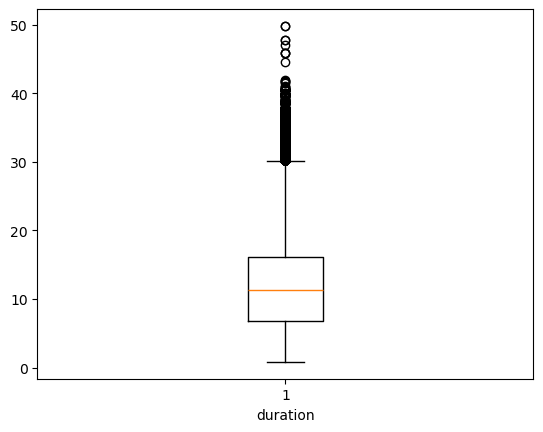

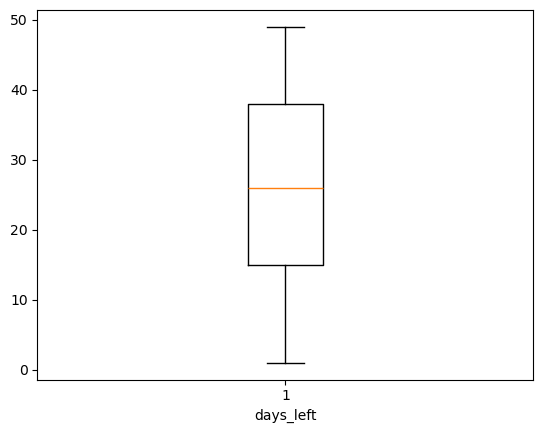

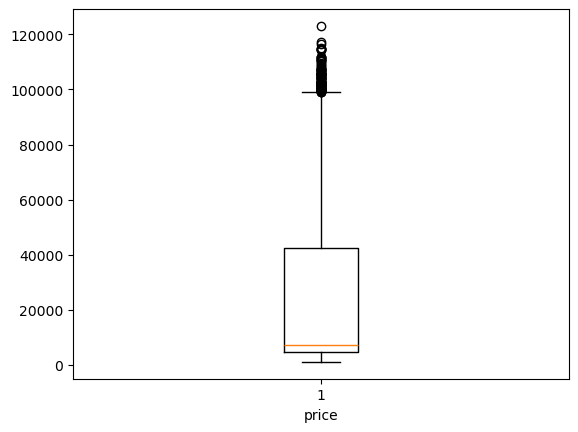

In [19]:
# checking for outlries
for i in df.columns:
    if df[i].dtype!='object':
        plt.boxplot(df[i])
        plt.xlabel(i)
        plt.show()



Data Preprocessing

In [21]:
df.drop('flight',axis=1,inplace=True)

KeyError: "['flight'] not found in axis"

In [22]:
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [23]:
df['stops'].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

In [24]:
#Covert stops to nnumericsl
df['stops']=df['stops'].replace({
    'zero':0,
    'one':1,
    'two_or_more':2
})

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5032\2294732219.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['stops']=df['stops'].replace({


In [25]:
#Apply One Hot Encoder
categorical_col=['airline','source_city','departure_time','arrival_time','destination_city','class']
df=pd.get_dummies(df,columns=categorical_col,drop_first=True)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 30 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   stops                         300153 non-null  int64  
 1   duration                      300153 non-null  float64
 2   days_left                     300153 non-null  int64  
 3   price                         300153 non-null  int64  
 4   airline_Air_India             300153 non-null  bool   
 5   airline_GO_FIRST              300153 non-null  bool   
 6   airline_Indigo                300153 non-null  bool   
 7   airline_SpiceJet              300153 non-null  bool   
 8   airline_Vistara               300153 non-null  bool   
 9   source_city_Chennai           300153 non-null  bool   
 10  source_city_Delhi             300153 non-null  bool   
 11  source_city_Hyderabad         300153 non-null  bool   
 12  source_city_Kolkata           300153 non-nul

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [28]:
col_list=[]

for i in df.columns:
  if (df[i].dtype!='object') and (i!='price'):
    col_list.append(i)

x=df[col_list]

x=x.astype(int)

vif_data=pd.DataFrame()
vif_data['Features']=x.columns
vif_data['VIF Score']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]

In [29]:
vif_data

,Features,VIF Score
0,stops,8.232025
1,duration,6.449762
2,days_left,4.383979
3,airline_Air_India,5.061768
4,airline_GO_FIRST,1.992489
5,airline_Indigo,2.802756
6,airline_SpiceJet,1.449455
7,airline_Vistara,7.101335
8,source_city_Chennai,1.730531
9,source_city_Delhi,2.091861


In [30]:
df.drop('stops',axis=1,inplace=True)

In [31]:
col_list=[]

for i in df.columns:
  if (df[i].dtype!='object') and (i!='price'):
    col_list.append(i)

x=df[col_list]

x=x.astype(int)

vif_data=pd.DataFrame()
vif_data['Features']=x.columns
vif_data['VIF Score']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]

In [ ]:
vif_data
df.drop('airline_Vistara',axis=1,inplace=True)

,Features,VIF Score
0,duration,4.927731
1,days_left,4.350982
2,airline_Air_India,5.045846
3,airline_GO_FIRST,1.979037
4,airline_Indigo,2.788941
5,airline_SpiceJet,1.445887
6,airline_Vistara,7.008753
7,source_city_Chennai,1.723238
8,source_city_Delhi,2.082977
9,source_city_Hyderabad,1.765531


In [35]:
x=df.drop('price',axis=1)
y=df['price']

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
x

,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,source_city_Chennai,source_city_Delhi,source_city_Hyderabad,source_city_Kolkata,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,2.17,1,False,False,False,True,False,True,False,False,...,False,False,False,True,False,False,False,False,True,True
1,2.33,1,False,False,False,True,False,True,False,False,...,False,False,True,False,False,False,False,False,True,True
2,2.17,1,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,True
3,2.25,1,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,True
4,2.33,1,False,False,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,10.08,49,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,True,False,False,False
300149,10.42,49,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False
300150,13.83,49,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False
300151,10.00,49,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,True,False,False,False


In [38]:
y

0          5953
1          5953
2          5956
3          5955
4          5955
          ...  
300148    69265
300149    77105
300150    79099
300151    81585
300152    81585
Name: price, Length: 300153, dtype: int64

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
sc=StandardScaler()

In [43]:
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

Model Building

In [44]:
from sklearn.linear_model import LinearRegression

In [45]:
lr=LinearRegression()

In [46]:
#Train the model
lr.fit(x_train,y_train)

LinearRegression()

In [47]:
#Test the Model
y_pred=lr.predict(x_test)

In [48]:
#Evaluate the model
from sklearn.metrics import *

In [51]:
r2_score(y_test,y_pred)

0.9021518090813911